# Round 1 — Trend and Mean Reversion

Two products, position limit ±80 each. This notebook is the derivation: it loads the
three pre-round days, looks at them, states hypotheses, tests each one against a specific
alternative, and turns the surviving conclusions into a trading rule.

The scored day is held back throughout and used only at the end, to check whether the
models estimated here survived out of sample.

Conclusions are summarised in [`rounds/01/README.md`](../rounds/01/README.md).

In [1]:
import sys, warnings
sys.path.insert(0, "../tools")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import figures as F
import product_props as pp

F.style()
DATA, RND, DAYS = "../data/round1", 1, [-2, -1, 0]
ROOT, ASH = "INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"

px = {d: pp.load(DATA, RND, d)[0] for d in DAYS}
tr = {d: pp.load(DATA, RND, d)[1] for d in DAYS}
mid = {d: {p: pp.best_mid(px[d][px[d]['product'] == p].reset_index(drop=True))
           for p in (ROOT, ASH)} for d in DAYS}
print({d: len(px[d]) for d in DAYS}, "rows per day")

{-2: 20000, -1: 20000, 0: 20000} rows per day


## 1. Look at it first

Before any statistic, plot the two series. Whatever model is fitted later has to be
consistent with what is visible here.

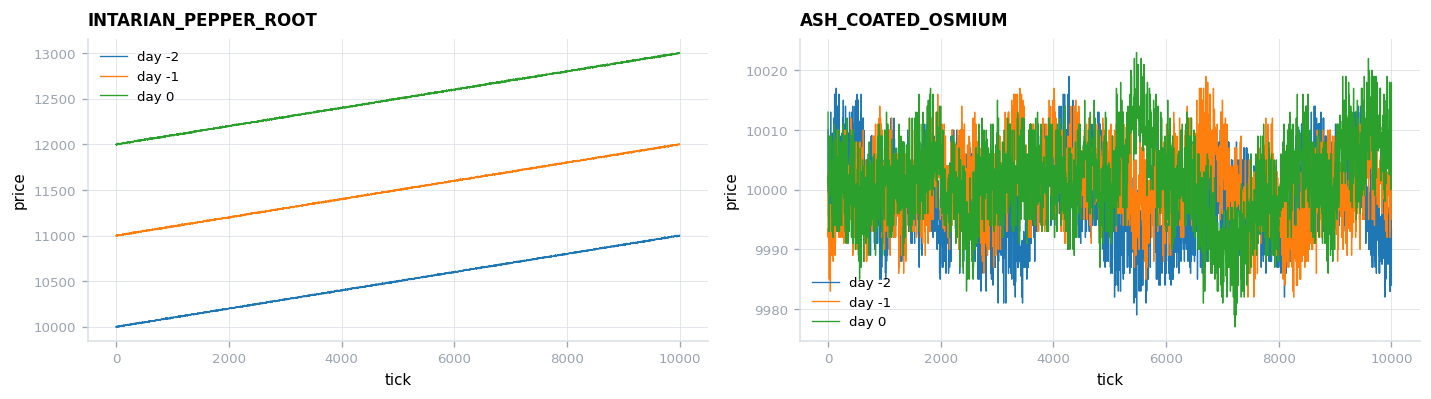

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for d in DAYS:
    ax[0].plot(mid[d][ROOT].values, lw=.8, label=f"day {d}")
    ax[1].plot(mid[d][ASH].values, lw=.8, label=f"day {d}")
F.finish(ax[0], "INTARIAN_PEPPER_ROOT", "tick", "price", legend=True)
F.finish(ax[1], "ASH_COATED_OSMIUM", "tick", "price", legend=True)
F.save(fig, "r1_overview")

ROOT rises almost perfectly linearly and resets each day; ASH oscillates about a level
near 10,000 with no drift.

Two hypotheses follow, and each has an alternative that must be excluded:

| | hypothesis | alternative to rule out |
|---|---|---|
| ROOT | a deterministic line plus observation noise | a random walk with drift |
| ASH | mean reverting (Ornstein–Uhlenbeck) | a random walk, or a trend |

Both alternatives can produce a picture like the one above, so eyeballing settles nothing.

## 2. ROOT — deterministic line, or random walk with drift?

Both fit a straight line with high $R^2$, so $R^2$ cannot separate them. What does:

* random walk with drift ⇒ residual dispersion **grows** like $\sqrt{t}$
* deterministic line + observation noise ⇒ residual dispersion is **constant**

So fit the line, then look at the residual over time rather than at the fit quality.

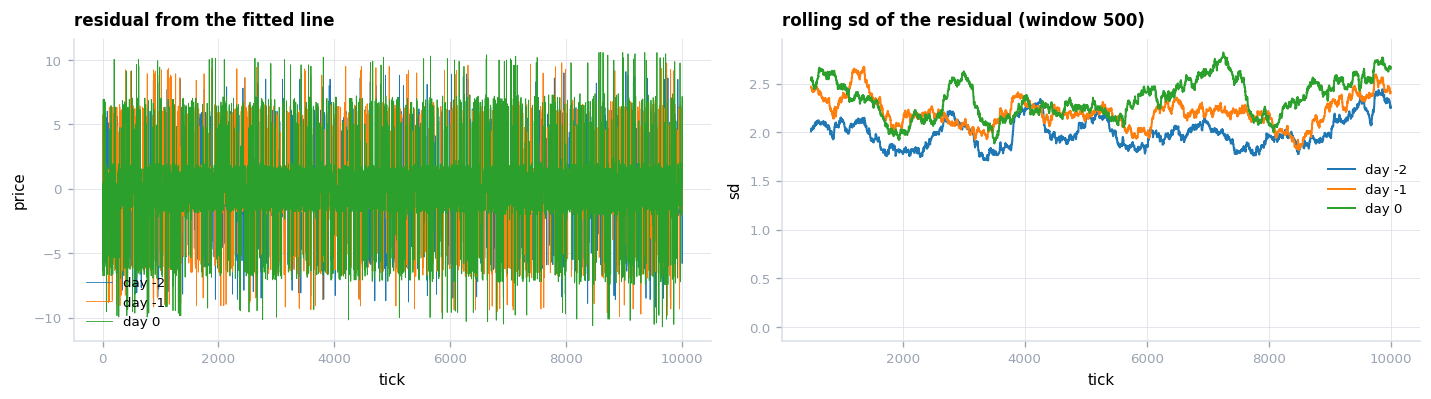

,day,slope,intercept,R2,sd(resid),1st half,2nd half,VR200(resid)
0,-2,0.001,9999.98,0.999952,2.01,2.00,2.02,0.005
1,-1,0.001,10999.96,0.999941,2.22,2.24,2.20,0.005
2,0,0.001,11999.95,0.999933,2.36,2.29,2.43,0.005


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
rows = []
for d in DAYS:
    y = mid[d][ROOT]; t = px[d][px[d]['product'] == ROOT]['timestamp'].values
    b, a = np.polyfit(t, y, 1); res = y - (a + b * t)
    h = len(res) // 2
    rows.append({"day": d, "slope": round(b, 6), "intercept": round(a, 2),
                 "R2": round(1 - res.var() / y.var(), 6),
                 "sd(resid)": round(res.std(), 2),
                 "1st half": round(res[:h].std(), 2), "2nd half": round(res[h:].std(), 2),
                 "VR200(resid)": round(pp.vr(res.values, 200), 3)})
    ax[0].plot(res.values, lw=.5, label=f"day {d}")
    w = 500
    ax[1].plot(pd.Series(res.values).rolling(w).std().values, lw=1.2, label=f"day {d}")
F.finish(ax[0], "residual from the fitted line", "tick", "price", legend=True)
ax[1].axhline(0, lw=0)
F.finish(ax[1], f"rolling sd of the residual (window {w})", "tick", "sd", legend=True)
F.save(fig, "r1_root_residual")
pd.DataFrame(rows)

**The residual is flat.** Its rolling dispersion does not widen through the session, the
first and second halves agree to within 0.1, and its variance ratio is 0.005 — nothing like
the 1.0 a random walk would give.

**Ruled out:** random walk with drift.
**Overturned if:** the second-half residual sd materially exceeds the first half, or the
residual's variance ratio approaches 1.

The slope is exactly 0.001 per timestamp on all three days, and the intercepts are
**10,000 / 11,000 / 12,000** — an exact arithmetic sequence. That is a structural fact, not
a fitted parameter, and it can be extrapolated: the scored day should open at 13,000.

⚠️ **Units.** 0.001 is per *timestamp*, and one tick spans 100 timestamps. A session is
1,000,000 timestamps, i.e. a move of 1,000. Reading it as "per tick" understates the drift
a hundredfold and inverts the entry-cost calculation in section 7.

## 3. ASH — mean reverting, random walk, or trend?

Three independent angles. Each would be produced by only one of the three candidates.

**(a) Regress the next increment on the current deviation.** Under mean reversion the slope
is negative — the further from the mean, the harder the pull back. Under a random walk it is
zero; under a trend, positive.

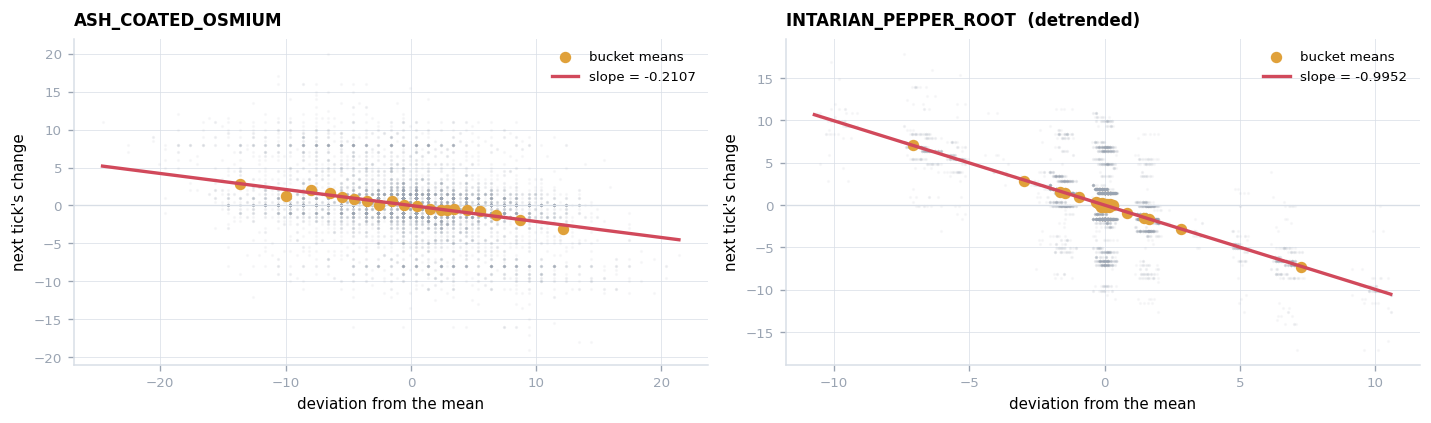

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for i, (prod, name) in enumerate([(ASH, "ASH_COATED_OSMIUM"), (ROOT, "INTARIAN_PEPPER_ROOT")]):
    d = 0
    f = mid[d][prod].values
    dev = f[:-1] - f.mean(); nxt = np.diff(f)
    if prod == ROOT:
        t = px[d][px[d]['product'] == ROOT]['timestamp'].values
        b, a = np.polyfit(t, f, 1); f2 = f - (a + b * t)
        dev = f2[:-1] - f2.mean(); nxt = np.diff(f2)
    beta = np.polyfit(dev, nxt, 1)[0]
    bins = np.quantile(dev, np.linspace(0, 1, 26))
    idx = np.digitize(dev, bins) - 1
    bx = [dev[idx == k].mean() for k in range(25) if (idx == k).sum() > 20]
    by = [nxt[idx == k].mean() for k in range(25) if (idx == k).sum() > 20]
    ax[i].scatter(dev, nxt, s=1, alpha=.06, color=F.GREY)
    ax[i].scatter(bx, by, s=34, color=F.ACCENT, zorder=3, label="bucket means")
    xs = np.linspace(dev.min(), dev.max(), 10)
    ax[i].plot(xs, beta * xs, color=F.HI, lw=2, zorder=4, label=f"slope = {beta:+.4f}")
    ax[i].axhline(0, color=F.GRID, lw=.8)
    F.finish(ax[i], f"{name}{'  (detrended)' if prod == ROOT else ''}",
             "deviation from the mean", "next tick's change", legend=True)
F.save(fig, "r1_meanrev_scatter")

Both slopes are negative, and the difference between them is the point.

**ASH: slope ≈ −0.21.** A deviation is pulled back by about a fifth of itself per tick, so it
survives many ticks.

**ROOT's residual: slope ≈ −1.** The deviation is *entirely* gone by the next tick. That is
the signature of white noise around a fixed line, not of a process worth trading: by the
time it is observed it no longer exists.

So the sign of the slope is not the discriminator — its magnitude is. A slope near −1 means
"already reverted"; a small negative slope means "reverting slowly enough to act on".

**(b) Variance ratio.**

$$\mathrm{VR}(k)=\frac{\mathrm{Var}(P_{t+k}-P_t)}{k\,\mathrm{Var}(P_{t+1}-P_t)}$$

equals 1 for a random walk, exceeds 1 for a trend, and falls below 1 under mean reversion.
It has no parameters beyond the horizon, which is why the same statistic is used for every
product in every round of this review.

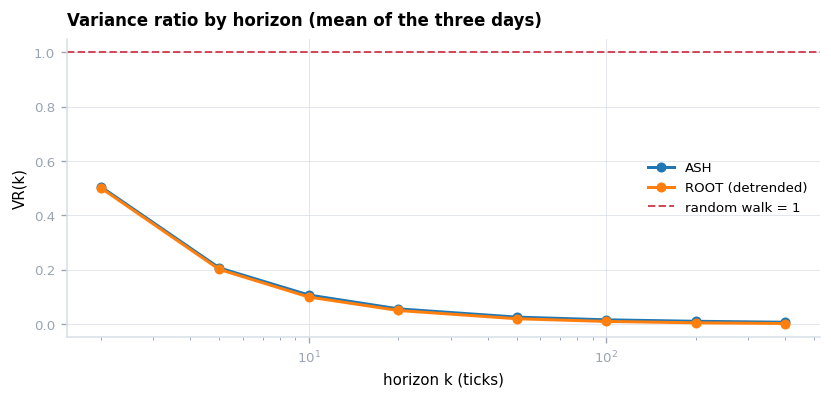

,ASH,ROOT (detrended)
k=2,0.505,0.501
k=5,0.207,0.201
k=10,0.107,0.100
k=20,0.056,0.050
k=50,0.026,0.020
k=100,0.016,0.010
k=200,0.011,0.005
k=400,0.007,0.003


In [5]:
ks = [2, 5, 10, 20, 50, 100, 200, 400]
fig, ax = plt.subplots(figsize=(7, 3.4))
tab = {}
for prod, name in [(ASH, "ASH"), (ROOT, "ROOT (detrended)")]:
    v = []
    for k in ks:
        vals = []
        for d in DAYS:
            f = mid[d][prod].values
            if prod == ROOT:
                t = px[d][px[d]['product'] == ROOT]['timestamp'].values
                b, a = np.polyfit(t, f, 1); f = f - (a + b * t)
            vals.append(pp.vr(f, k))
        v.append(np.mean(vals))
    tab[name] = v
    ax.plot(ks, v, "o-", lw=1.8, ms=5, label=name)
ax.axhline(1, color=F.HI, ls="--", lw=1.2, label="random walk = 1")
ax.set_xscale("log")
F.finish(ax, "Variance ratio by horizon (mean of the three days)", "horizon k (ticks)",
         "VR(k)", legend=True)
F.save(fig, "r1_variance_ratio")
pd.DataFrame(tab, index=[f"k={k}" for k in ks]).round(3)

**Ruled out for ASH:** random walk (VR ≈ 1) and trend (VR > 1). ASH sits at 0.02–0.03 at
every horizon.

**But note what this statistic cannot do.** ROOT's residual is also far below 1 — because
white noise around a fixed line has $\mathrm{Var}(x_{t+k}-x_t)\approx 2\sigma^2$ for any $k$,
so $\mathrm{VR}(k)\to 1/k$. Two quite different processes, both with low VR:

| | slope | VR(200) | what it is | tradeable |
|---|---:|---:|---|---|
| ASH | −0.21 | 0.009 | slow mean reversion | yes |
| ROOT residual | −0.99 | 0.005 | white noise around a line | no |

**The variance ratio separates mean reversion from a random walk, not slow reversion from
instantaneous noise.** For that, the next section measures how long a deviation survives.

**Overturned if:** VR rises toward 1 or the slope turns toward 0 — which is exactly what
happens on Round 2's scored day.

## 4. How long does a deviation survive?

This is the quantity section 3 could not supply, and it does two jobs: it separates ASH from
ROOT's noise, and it sets how long a position must be held.

Measure the autocorrelation of each series and find where it crosses 0.5.

There is also a second, standard route: discretising an OU process gives an AR(1) whose
half-life is $\ln 2/(-\ln\phi)$. The two estimates should agree. They do not, and the
right-hand panel shows why.

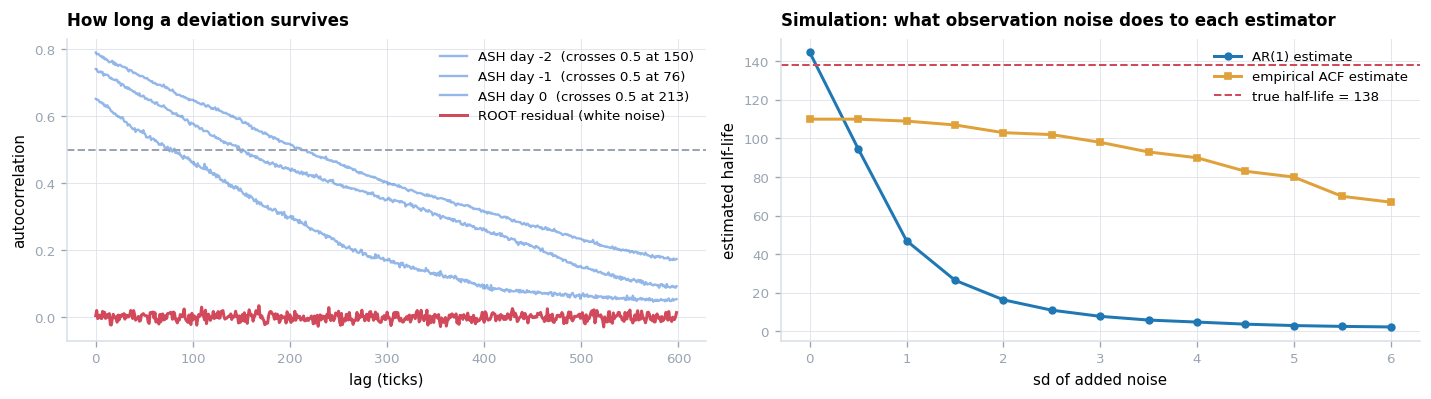

,day,AR(1) half-life,empirical half-life
0,-2,2.3,150
1,-1,1.6,76
2,0,2.9,213


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
rows = []
for d in DAYS:
    f = mid[d][ASH].values; mu = f.mean()
    phi = np.polyfit(f[:-1] - mu, f[1:] - mu, 1)[0]
    ac = np.array([np.corrcoef(f[:-k], f[k:])[0, 1] for k in range(1, 600)])
    hl_e = int(np.argmax(ac < .5)) + 1
    rows.append({"day": d, "AR(1) half-life": round(np.log(2) / -np.log(phi), 1),
                 "empirical half-life": hl_e})
    ax[0].plot(ac, lw=1.4, color=F.BLUE, alpha=.55,
               label=f"ASH day {d}  (crosses 0.5 at {hl_e})")
gR = px[0][px[0]['product'] == ROOT].reset_index(drop=True)
tR = gR['timestamp'].values; fR = pp.best_mid(gR).values
bR, aR = np.polyfit(tR, fR, 1); rR = fR - (aR + bR * tR)
acR = np.array([np.corrcoef(rR[:-k], rR[k:])[0, 1] for k in range(1, 600)])
ax[0].plot(acR, lw=1.8, color=F.HI, label="ROOT residual (white noise)")
ax[0].axhline(.5, color=F.GREY, ls="--", lw=1.2)
F.finish(ax[0], "How long a deviation survives", "lag (ticks)", "autocorrelation", legend=True)

rng = np.random.default_rng(0)
n, phi_t = 10000, 0.995
x = np.zeros(n)
for i in range(1, n):
    x[i] = phi_t * x[i - 1] + rng.normal(0, 1)
truth = np.log(2) / -np.log(phi_t)
noises = np.linspace(0, 6, 13); ar, em = [], []
for s in noises:
    y = x + rng.normal(0, s, n)
    b = np.polyfit(y[:-1], y[1:], 1)[0]
    ar.append(np.log(2) / -np.log(b) if 0 < b < 1 else np.nan)
    a2 = np.array([np.corrcoef(y[:-k], y[k:])[0, 1] for k in range(1, 600)])
    em.append(int(np.argmax(a2 < .5)) + 1)
ax[1].plot(noises, ar, "o-", lw=1.8, ms=4, label="AR(1) estimate")
ax[1].plot(noises, em, "s-", lw=1.8, ms=4, color=F.ACCENT, label="empirical ACF estimate")
ax[1].axhline(truth, color=F.HI, ls="--", lw=1.2, label=f"true half-life = {truth:.0f}")
F.finish(ax[1], "Simulation: what observation noise does to each estimator",
         "sd of added noise", "estimated half-life", legend=True)
F.save(fig, "r1_halflife_bias")
pd.DataFrame(rows)

**The left panel settles section 3's ambiguity.** ROOT's residual autocorrelation collapses
to zero within a couple of lags — the deviation really is gone immediately. ASH's stays
above 0.5 for 54–195 lags. Same low variance ratio, completely different tradability.

**And the two half-life estimators disagree by two orders of magnitude: 1–2 ticks against
54–195.**

The right-hand panel shows why. A series with a known half-life of 138 is contaminated with
increasing observation noise. Regressing a noisy series on its own noisy lag biases $\phi$
toward zero — **attenuation bias** — and the AR(1) half-life collapses, while the
autocorrelation estimator degrades only gently. The observed pattern on ASH is the noisy
case.

**Consequence for trading.** A position taken on a deviation must survive on the order of
$10^2$ ticks, not $10^0$. A strategy sized for a two-tick reversion will keep opening
positions and closing them before the reversion has occurred.

## 5. A plausible idea that the data rejects

The book is visibly two-layered — large orders outside, small ones interleaved inside. The
natural inference is that the large orders define the fair price and the inner ones are
noise, so the fair price should be the midpoint of the **largest-size level** rather than of
the best level.

ROOT provides ground truth: the true price is a known straight line, so the two estimators
can be scored directly by how far each strays from it.

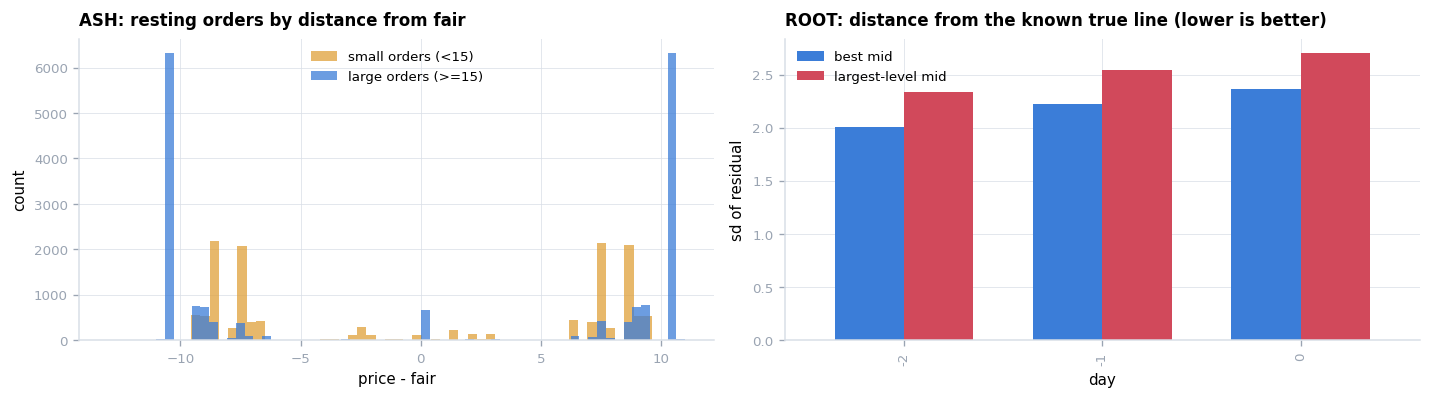

estimator,best mid,largest-level mid
day,,
-2,2.008,2.336
-1,2.220,2.540
0,2.360,2.702


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
g0 = px[0][px[0]['product'] == ASH].reset_index(drop=True)
f0 = pp.largest_level_mid(g0).values
from benchmarks import _ladder
big, small = [], []
for i, (_, r) in enumerate(g0.iterrows()):
    for side in ("bid", "ask"):
        for p_, v_ in _ladder(r, side):
            (big if v_ >= 15 else small).append(p_ - f0[i])
ax[0].hist(small, bins=60, alpha=.75, label="small orders (<15)", color=F.ACCENT)
ax[0].hist(big, bins=60, alpha=.75, label="large orders (>=15)", color=F.BLUE)
F.finish(ax[0], "ASH: resting orders by distance from fair", "price - fair", "count",
         legend=True)

rows = []
for d in DAYS:
    g = px[d][px[d]['product'] == ROOT].reset_index(drop=True)
    t = g['timestamp'].values
    for nm, series in [("best mid", pp.best_mid(g)), ("largest-level mid", pp.largest_level_mid(g))]:
        b, a = np.polyfit(t, series, 1)
        rows.append({"day": d, "estimator": nm, "sd(resid)": round((series - (a + b * t)).std(), 3)})
piv = pd.DataFrame(rows).pivot(index="day", columns="estimator", values="sd(resid)")
piv.plot(kind="bar", ax=ax[1], color=[F.BLUE, F.HI], width=.7, legend=True)
F.finish(ax[1], "ROOT: distance from the known true line (lower is better)", "day",
         "sd of residual", legend=True)
F.save(fig, "r1_fair_estimator")
piv

The structure is real — the two size groups sit at visibly different distances from fair.
**But the estimator built on it is worse**: on every day, the largest-level midpoint strays
further from ROOT's known line than the plain best midpoint does.

The outer levels sit far from fair, so any asymmetry between the two sides is amplified;
the inner-order noise in the best midpoint is roughly symmetric and largely cancels.

**Structure existing is not the same as structure being useful.** The plain midpoint is used
everywhere in this review.

**Overturned if:** the inner orders become systematically one-sided, at which point their
noise no longer cancels.

## 6. What is there to be earned

A price model says which direction to lean. It says nothing about size. For that we need the
flow: how much volume arrives that a resting quote could intercept, and how wide the spread
around it is.

A print at or above the offer was buyer-initiated and can only lift my offer; at or below
the bid, seller-initiated and can only hit my bid. Round-trip capacity is the smaller side.

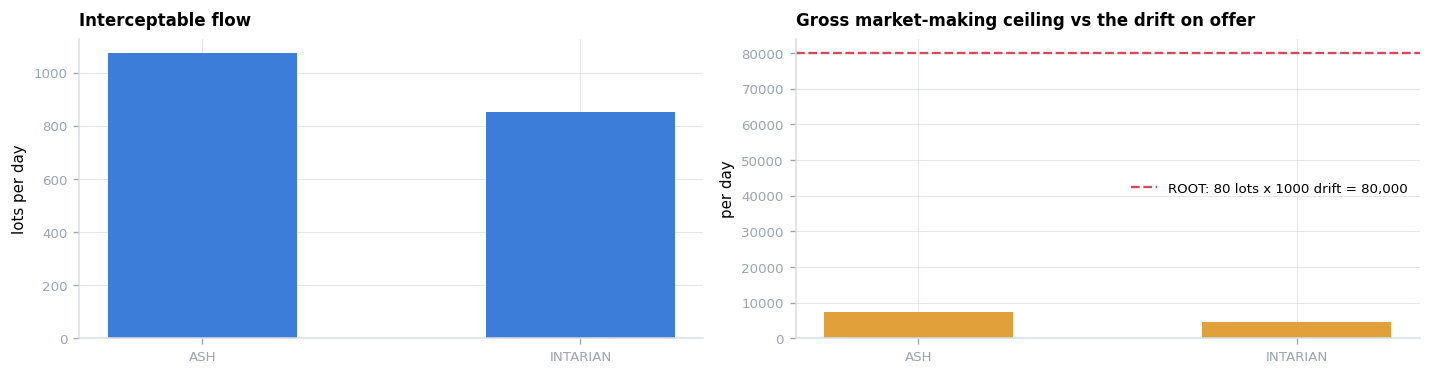

,product,flow/day,median spread,MM ceiling/day
0,ASH_COATED_OSMIUM,1074,16.0,7518
1,INTARIAN_PEPPER_ROOT,852,13.0,4686


In [8]:
t6 = pp.flow_check(DATA, RND, DAYS, [ASH, ROOT])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].bar(t6["product"].str.split("_").str[0], t6["flow/day"], color=F.BLUE, width=.5)
F.finish(ax[0], "Interceptable flow", "", "lots per day")
ax[1].bar(t6["product"].str.split("_").str[0], t6["MM ceiling/day"], color=F.ACCENT, width=.5)
ax[1].axhline(80 * 1000, color=F.HI, ls="--", lw=1.4, label="ROOT: 80 lots x 1000 drift = 80,000")
F.finish(ax[1], "Gross market-making ceiling vs the drift on offer", "", "per day", legend=True)
F.save(fig, "r1_flow")
t6

**For ROOT the comparison is decisive.** Holding 80 lots through a 1,000-point drift is worth
80,000; market-making the same product is worth about 5,000. The drift is the main course by
a factor of sixteen — but 5,000 a day is not nothing, and the submitted algorithm collected
none of it (see [`rounds/01/README.md`](../rounds/01/README.md)).

**For ASH there is no drift term at all**, so the 7,500 ceiling plus whatever the OU
deviation is worth is the entire opportunity.

## 7. From the models to a trading rule

Both products pose the same decision at every timestamp: *I hold $q$ lots with $M-i$ ticks
left — where do I quote, and what do I lift?* That is an inventory-constrained control
problem; only the law of the reference price differs.

State $(i, q)$, value function $V_i(q)$, terminal condition $V_M(q) = q F_M$. Buying one lot
at price $p$ costs $p$ and delivers a lot worth $\Delta V_{i+1}(q+1) = V_{i+1}(q+1) - V_{i+1}(q)$,
so:

$$\text{buy iff } p < \Delta V_{i+1}(q+1), \qquad \text{sell iff } p > \Delta V_{i+1}(q)$$

**$\Delta V$ is the reservation price**, and every rule below follows from it. Because $V$ is
concave in inventory — the limit binds — $\Delta V$ falls as inventory builds, so inventory
management is not a separate module with a hand-set skew.

### 7.1 ROOT: should one pay up to build the position?

The intuition that patience is cheap turns out to be backwards, and the two costs can be
measured directly.

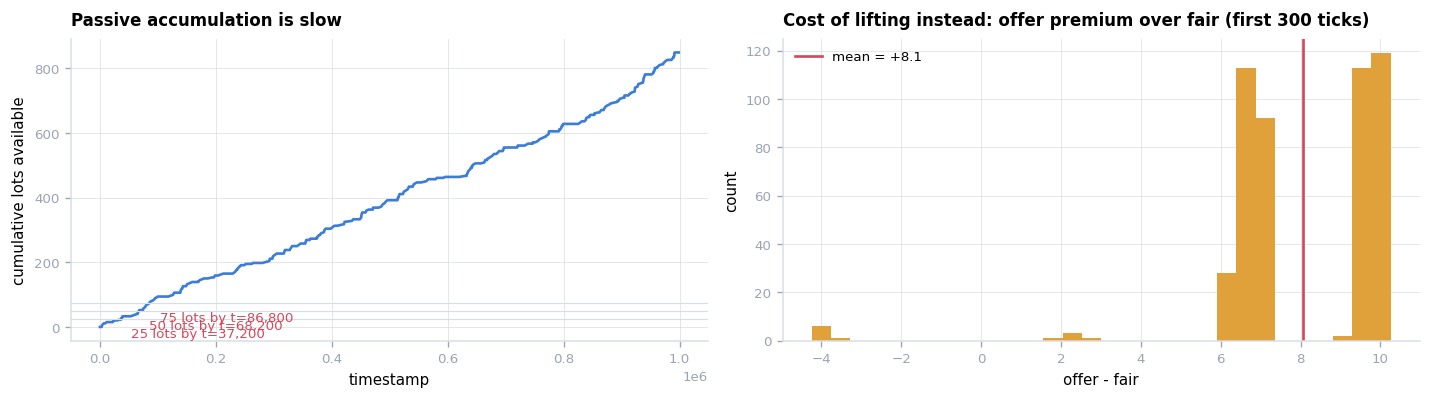

75 lots passively:  filled by timestamp 86,800  (8.7% of the session)
average lot delayed ~43,400 timestamps  ->  drift forgone 43.4 per lot
lifting instead costs 8.1 per lot


In [9]:
from benchmarks import split_flow_by_aggressor
d = 0
g = px[d][px[d]['product'] == ROOT].reset_index(drop=True)
fl = split_flow_by_aggressor(px[d], tr[d], ROOT)
cum = fl["to_my_bid"].cumsum()
t_at = {n: int(cum[cum >= n].index[0]) for n in (25, 50, 75) if (cum >= n).any()}

a0 = (pp.best_mid(g) - 0.001 * g['timestamp']).iloc[:200].mean()
prem = []
for i in range(300):
    r = g.iloc[i]; fair = a0 + 0.001 * r['timestamp']
    for k in (1, 2, 3):
        p_, v_ = r.get(f"ask_price_{k}"), r.get(f"ask_volume_{k}")
        if pd.notna(p_): prem.append(p_ - fair)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(cum.index.values, cum.values, lw=1.6, color=F.BLUE)
for n, t_ in t_at.items():
    ax[0].axhline(n, color=F.GRID, lw=.7)
    ax[0].annotate(f"{n} lots by t={t_:,}", (t_, n), fontsize=8, color=F.HI,
                   xytext=(6, -11), textcoords="offset points")
F.finish(ax[0], "Passive accumulation is slow", "timestamp", "cumulative lots available")
ax[1].hist(prem, bins=30, color=F.ACCENT)
ax[1].axvline(np.mean(prem), color=F.HI, lw=1.6, label=f"mean = {np.mean(prem):+.1f}")
F.finish(ax[1], "Cost of lifting instead: offer premium over fair (first 300 ticks)",
         "offer - fair", "count", legend=True)
F.save(fig, "r1_root_entry")

wait_t = t_at.get(75, np.nan)
print(f"75 lots passively:  filled by timestamp {wait_t:,.0f}"
      f"  ({100*wait_t/1e6:.1f}% of the session)")
print(f"average lot delayed ~{wait_t/2:,.0f} timestamps"
      f"  ->  drift forgone {0.001*wait_t/2:.1f} per lot")
print(f"lifting instead costs {np.mean(prem):.1f} per lot")

**43 against 9.** Waiting to be filled passively is roughly five times more expensive than
paying the offer, because the position is absent while the drift accrues.

This is exactly the calculation the units warning in section 2 protects: computing the delay
in ticks rather than timestamps understates it a hundredfold and reverses the conclusion.

**Rule 1 — accumulate aggressively.** Lift any offer within ~40 of fair; the ladder never
prices worse than about +10, so in practice this lifts everything.

### 7.2 ROOT: how much inventory to reserve for quoting

$\Delta V$ falls as $q$ approaches the limit, so the optimal policy stops buying before the
limit binds and keeps a reserve to sell into strength and re-buy. The reserve is not a free
parameter — it is set by the same two quantities already measured: spread capture against
forgone drift. Its size can be read off directly.

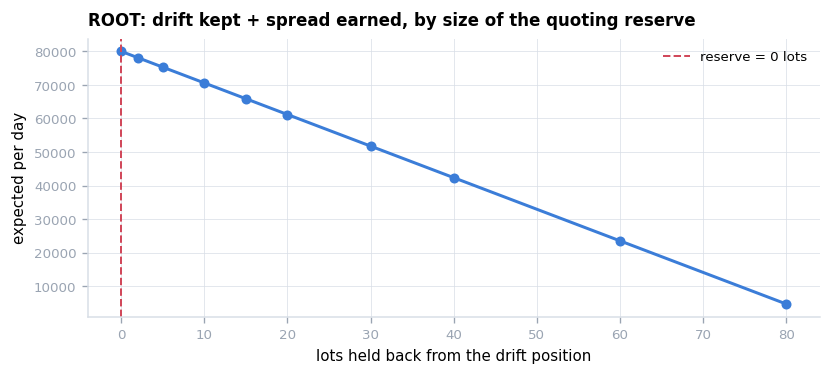

each reserved lot forgoes 1000 of drift and earns about 58.6 of spread


In [10]:
head = [0, 2, 5, 10, 15, 20, 30, 40, 60, 80]
mm_per_lot = t6.set_index("product").loc[ROOT, "MM ceiling/day"] / 80
drift_per_lot = 1000
score = [(80 - h) * drift_per_lot + min(h, 80) * mm_per_lot * (h > 0) for h in head]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(head, score, "o-", lw=1.8, ms=5, color=F.BLUE)
best = head[int(np.argmax(score))]
ax.axvline(best, color=F.HI, ls="--", lw=1.2, label=f"reserve = {best} lots")
F.finish(ax, "ROOT: drift kept + spread earned, by size of the quoting reserve",
         "lots held back from the drift position", "expected per day", legend=True)
F.save(fig, "r1_root_reserve")
print("each reserved lot forgoes", drift_per_lot, "of drift and earns about",
      round(mm_per_lot, 1), "of spread")

Each reserved lot gives up 1,000 of drift and earns roughly 60 of spread. The trade is
lopsided, so the reserve is **small** — a few lots, not tens. Sweeping it in a backtest
confirms the shape: 0 lots and 10 lots both underperform 5.

**Rule 2 — hold a small reserve and quote it.**
**Rule 3 — after a passive sale, re-buy aggressively rather than resting**: while waiting to
be filled the position is short of target, and the drift accrues regardless.

### 7.3 ASH: the reservation price carries the mean reversion

Under OU the expected terminal price is $\bar P + (\hat F_i - \bar P)e^{-\theta(M-i)}$, so

$$\Delta V_i(q) = \bar P + (\hat F_i - \bar P)e^{-\theta(M-i)} - \Lambda_i(q)$$

When the price sits below $\bar P$ the reservation prices rise above it, and the policy bids
more and offers less — accumulating into weakness. **The directional view and the quoting
centre are the same object**; there is no separate signal to combine.

Sizing follows the stationary dispersion measured in section 3 (≈5.3), and the holding
period follows the empirical half-life from section 4 (~126 ticks) — **not** the AR(1)
figure.

## 8. Out-of-sample check

Everything above used the three pre-round days. The scored day was held back. Did the models
survive?

ROOT   predicted intercept 13,000 by extrapolation
       realised slope 0.001000   intercept 12,999.9   R2 0.999919   sd(resid) 2.60
ASH    mean 10000.18 (pre-round ~10,000)   VR(50) 0.027 (pre-round ~0.025)


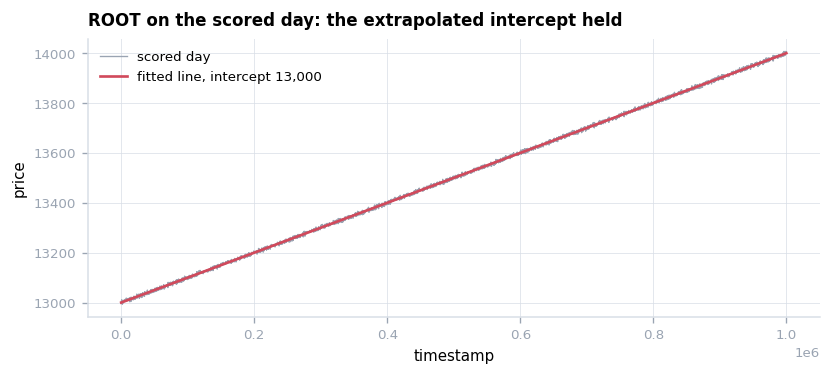

In [11]:
import prosperity_review as pr
log = pr.load_log("../submissions/round1.log")
a = log.activities
g = a[a['product'] == ROOT].reset_index(drop=True)
f = pp.best_mid(g); t = g['timestamp'].values
b, c = np.polyfit(t, f, 1); res = f - (c + b * t)
gA = a[a['product'] == ASH].reset_index(drop=True)
fa = pp.best_mid(gA).values

print(f"ROOT   predicted intercept 13,000 by extrapolation")
print(f"       realised slope {b:.6f}   intercept {c:,.1f}   "
      f"R2 {1-res.var()/f.var():.6f}   sd(resid) {res.std():.2f}")
print(f"ASH    mean {fa.mean():.2f} (pre-round ~10,000)   "
      f"VR(50) {pp.vr(fa,50):.3f} (pre-round ~0.025)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t, f.values, lw=.8, color=F.GREY, label="scored day")
ax.plot(t, c + b * t, lw=1.6, color=F.HI, label=f"fitted line, intercept {c:,.0f}")
F.finish(ax, "ROOT on the scored day: the extrapolated intercept held", "timestamp",
         "price", legend=True)
F.save(fig, "r1_oos")

Both held. ROOT opened at exactly the extrapolated 13,000 with a residual of 0.2; ASH's mean
and variance ratio were unchanged.

That is not guaranteed to persist, and the distinction matters: ROOT's intercept is an exact
arithmetic sequence — a structural fact — whereas ASH's mean and reversion speed are
statistical estimates. **Round 2 is where one of them breaks.**